<a href="https://colab.research.google.com/github/ShamimtheAnalyst/Crash-Course/blob/main/Lubridate_The_Ultimate_Guide_to_Date_%26_Time_in_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Lubridate: The Ultimate Guide to Date & Time in R**

### **নোটবুক পরিচিতি (Metadata)**

* **Aim:** আর (R) এবং `lubridate` ব্যবহার করে তারিখ ও সময় তৈরি, পরিবর্তন এবং বিশ্লেষণ করা।
* **Dataset:** `nycflights13` (নিউ ইয়র্ক সিটির ২০১৩ সালের সব ফ্লাইটের তথ্য)।
* **Key Learnings:** ডেট-টাইম অবজেক্ট তৈরি, কম্পোনেন্ট এক্সট্রাকশন (Weekdays, Months), এবং সময়সীমা (Durations, Periods, Intervals) নিয়ন্ত্রণ।

### **১. এনভায়রনমেন্ট এবং ডেটা পরিচিতি**

শুরুতেই প্রয়োজনীয় লাইব্রেরি এবং ২০১৩ সালের ফ্লাইটের ডাটাসেটটি লোড করি।

In [4]:
#install.packages('lubridate')
#install.packages('nycflights13')

library(tidyverse)
library(lubridate)
library(nycflights13)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [5]:
# বর্তমান সময় দেখা
now()


[1] "2026-02-13 04:35:19 UTC"

In [6]:
# ডাটাসেটের এক ঝলক
glimpse(flights)

Rows: 336,776
Columns: 19
$ year           <int> 2013, 2013, 2013, 2013, 2013, 2013, 2013, 2013, 2013, 2…
$ month          <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1…
$ day            <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1…
$ dep_time       <int> 517, 533, 542, 544, 554, 554, 555, 557, 557, 558, 558, …
$ sched_dep_time <int> 515, 529, 540, 545, 600, 558, 600, 600, 600, 600, 600, …
$ dep_delay      <dbl> 2, 4, 2, -1, -6, -4, -5, -3, -3, -2, -2, -2, -2, -2, -1…
$ arr_time       <int> 830, 850, 923, 1004, 812, 740, 913, 709, 838, 753, 849,…
$ sched_arr_time <int> 819, 830, 850, 1022, 837, 728, 854, 723, 846, 745, 851,…
$ arr_delay      <dbl> 11, 20, 33, -18, -25, 12, 19, -14, -8, 8, -2, -3, 7, -1…
$ carrier        <chr> "UA", "UA", "AA", "B6", "DL", "UA", "B6", "EV", "B6", "…
$ flight         <int> 1545, 1714, 1141, 725, 461, 1696, 507, 5708, 79, 301, 4…
$ tailnum        <chr> "N14228", "N24211", "N619AA", "N804JB", "N668DN", "N394…
$ origin      

### **২. ডেট-টাইম অবজেক্ট তৈরি করা (Creating Objects)**

সাধারণত ডাটাসেটে বছর, মাস এবং দিন আলাদা আলাদা কলামে থাকে। সেগুলোকে একত্রিত করে একটি প্রমিত 'Date-Time' ফরমেটে আনা জরুরি।

In [7]:
# পদ্ধতি ১: টেক্সট থেকে ডেট-টাইম (ymd_hm)
flights %>%
  mutate(flight_date = ymd_hm(paste(year, month, day, hour, minute))) %>%
  select(origin, dest, flight_date) %>%
  head(4)

origin,dest,flight_date
<chr>,<chr>,<dttm>
EWR,IAH,2013-01-01 05:15:00
LGA,IAH,2013-01-01 05:29:00
JFK,MIA,2013-01-01 05:40:00
JFK,BQN,2013-01-01 05:45:00


In [8]:
# পদ্ধতি ২: কলাম থেকে সরাসরি (make_datetime) - এটি অনেক বেশি দক্ষ পদ্ধতি
flights %>%
  mutate(flight_date = make_datetime(year, month, day, hour, minute)) %>%
  select(origin, dest, flight_date) %>%
  head(4)

origin,dest,flight_date
<chr>,<chr>,<dttm>
EWR,IAH,2013-01-01 05:15:00
LGA,IAH,2013-01-01 05:29:00
JFK,MIA,2013-01-01 05:40:00
JFK,BQN,2013-01-01 05:45:00


### **৩. ডেটা থেকে নির্দিষ্ট তথ্য বের করা (Extracting Components)**

একটি তারিখ থেকে বার (Weekday) বা মাসের নাম বের করা ভিজ্যুয়ালাইজেশনের জন্য খুবই কার্যকর।

In [9]:
flights %>%
  mutate(flight_date = make_datetime(year, month, day)) %>%
  mutate(weekday = wday(flight_date, label = TRUE), # শনি, রবি ইত্যাদি
         month_name = month(flight_date, label = TRUE)) %>%
  select(origin, flight_date, weekday, month_name) %>%
  head(4)

origin,flight_date,weekday,month_name
<chr>,<dttm>,<ord>,<ord>
EWR,2013-01-01,Tue,Jan
LGA,2013-01-01,Tue,Jan
JFK,2013-01-01,Tue,Jan
JFK,2013-01-01,Tue,Jan


### **৪. টাইম স্প্যান (Durations, Periods, and Intervals)**

`lubridate` এ সময়ের দৈর্ঘ্য তিনভাবে পরিমাপ করা হয়। এটি অনেকের কাছে বিভ্রান্তিকর মনে হতে পারে, তাই নিচের পার্থক্যটি মনে রাখা জরুরি:

* **Duration (স্থায়িত্ব):** এটি সঠিক সেকেন্ডের হিসেবে চলে (Leap year বা DST হিসাব করে না)। এর শুরুতে `d` থাকে (যেমন: `dyears(1)`)।
* **Period (সময়কাল):** এটি ক্যালেন্ডারের সাধারণ হিসেবে চলে (Leap year হিসাব করে)। যেমন: `years(1)`।
* **Interval (বিরতি):** একটি নির্দিষ্ট শুরুর বিন্দু এবং শেষ বিন্দুর মধ্যবর্তী সময়।

In [10]:
# ১ বছর যোগ করার পার্থক্য
# Duration: ৩৬৫ দিন যোগ করবে
ymd("2016-01-01") + dyears(1)

[1] "2016-12-31 06:00:00 UTC"

In [11]:
# Period: ২০১৬ লিপ ইয়ার হওয়ায় ৩৬৬ দিন হিসাব করবে
ymd("2016-01-01") + years(1)

[1] "2017-01-01"

In [12]:
# ইন্টারভ্যাল এবং চেক
start <- ymd_hms("2024-01-01 12:00:00")
end   <- ymd_hms("2024-05-01 12:00:00")
iv    <- interval(start, end)

# একটি নির্দিষ্ট তারিখ কি এই ইন্টারভ্যালের ভেতরে?
ymd_hms("2024-04-01 12:00:00") %within% iv

[1] TRUE

### **৫. ভিজ্যুয়ালাইজেশন (Working with ggplot2)**

তারিখ এবং সময়ের ডেটা ব্যবহার করে আমরা সহজেই ফ্লাইটের সংখ্যা বা ট্রেন্ড দেখতে পারি।

#### **ক) বার চার্ট: সপ্তাহের দিন অনুযায়ী ফ্লাইটের সংখ্যা**

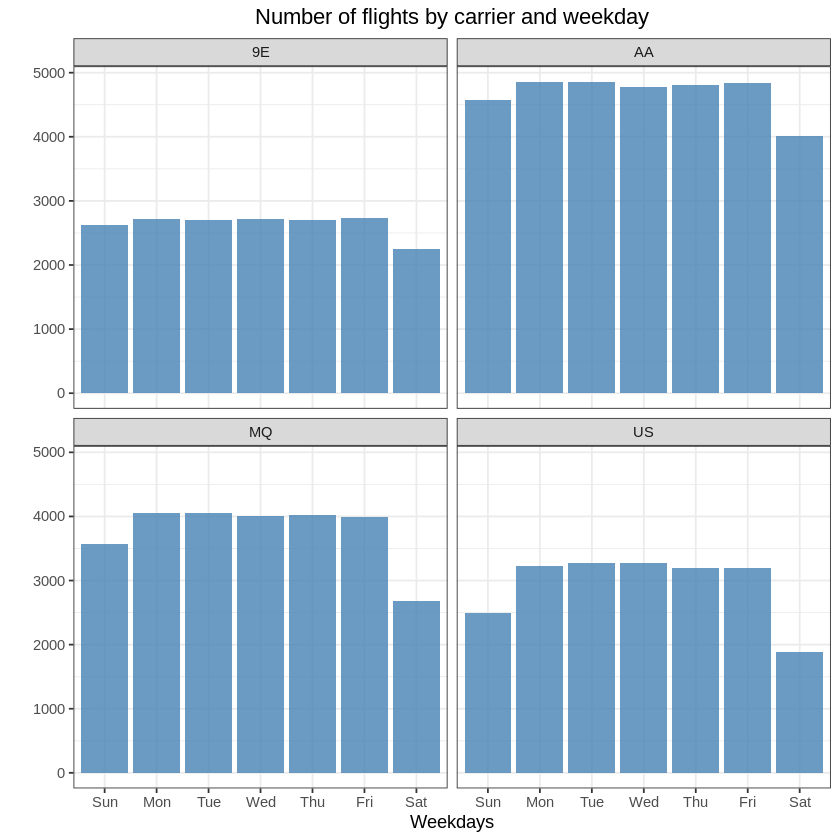

In [13]:
flights %>%
  filter(carrier %in% c("9E", "US", "AA", "MQ")) %>%
  mutate(weekday = wday(time_hour, label = TRUE)) %>%
  ggplot(aes(weekday)) +
  geom_bar(fill = "steelblue", alpha = 0.8) +
  facet_wrap( ~carrier) +
  theme_bw() +
  labs(title = "Number of flights by carrier and weekday", x = "Weekdays", y = "") +
  theme(plot.title = element_text(hjust = 0.5))

#### **খ) ফ্রিকোয়েন্সি পলিগন: সময়ের সাথে ফ্লাইটের ট্রেন্ড**

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


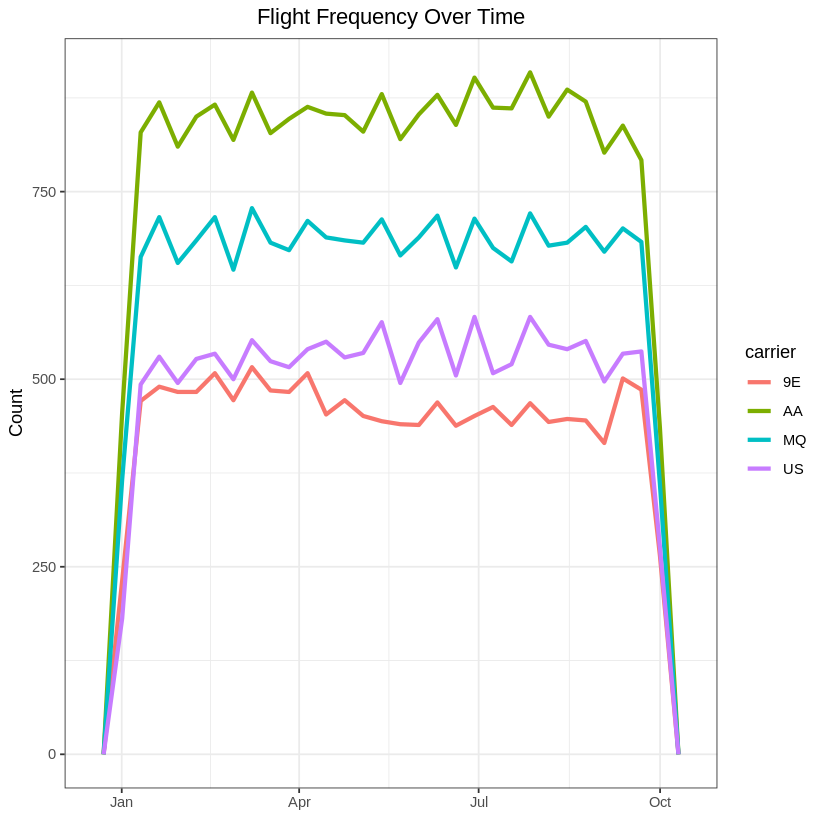

In [14]:
flights %>%
  filter(time_hour < ymd("2013-10-01"),
         carrier %in% c("9E", "US", "AA", "MQ")) %>%
  ggplot(aes(time_hour, color = carrier)) +
  geom_freqpoly(linewidth = 1.2) +
  theme_bw() +
  labs(title = "Flight Frequency Over Time", x = "", y = "Count") +
  theme(plot.title = element_text(hjust = 0.5))

### **এক নজরে প্রো-টিপস (Cheat Sheet):**

* **`ymd()` / `mdy()` / `dmy()**`: টেক্সটকে তারিখে রূপান্তরের সবচেয়ে সহজ উপায়।
* **`make_datetime()`**: যখন আলাদা আলাদা কলাম থাকে, তখন এটি ব্যবহার করা সবচেয়ে নিরাপদ।
* **`%within%`**: কোনো তারিখ একটি নির্দিষ্ট রেঞ্জের মধ্যে আছে কি না তা চেক করার জন্য।
* **Arithmetic**: গাণিতিক কাজের জন্য `Period` (যেমন: `months(1)`) ব্যবহার করা বেশি নির্ভরযোগ্য কারণ এটি ক্যালেন্ডারের পরিবর্তনগুলো (লিপ ইয়ার) খেয়াল রাখে।

---

**দারুণ!** আপনি এখন সময়ের সাথে তাল মিলিয়ে ডেটা এনালাইসিস করার জন্য পুরোপুরি তৈরি।